# Identification of a 2-DOF Mass-Spring-Damper System with the LSCE Algorithm

***

This notebook demonstrates the identification of a 2-DOF mass-spring-damper system using the Least Squares Complex Exponential (LSCE) algorithm. The system is excited by random and sine sweep signals and the response is measured at the two masses. The natural frequencies and damping ratios of the system are estimated from the measured response data.

* [Theoretical Background](#theoretical-background)
    * [Natural Frequency and Damping Ratio for a 2-DOF System](#natural-frequency-damping-ratio)
    * [LSCE Algorithm for a 2-DOF System](#lsce-algorithm)
    * [Calculation of the Mode Shapes](#mode-shapes)
* [Parameter Estimation from Random Excitation](#estimation-random)
    * [Data Generation](#data-generation)
    * [Data Processing](#data-processing)
    * [Parameter Estimation](#parameter-estimation)

## Theoretical Background <a name="theoretical-background"></a>

***

### Natural Frequency and Damping Ratio for a 2-DOF System <a name="natural-frequency-damping-ratio"></a>

Building on the 1-DOF system discussed in our first notebooks, we can expand our understanding to 2-DOF systems, which introduce important new concepts like mode shapes and modal damping.

Let's consider the 2-DOF mass-spring-damper system in the image below.

![2-DOF Mass-Spring-Damper System](resources/03_2DofMassSpringDamper.svg)

Here, mass $m_2$ is connected to mass $m_1$ by spring $k_2$ and damper $c_2$, and mass $m_1$ is connected to a fixed wall by spring $k_1$ and damper $c_1$. A single force $F(t)$ is applied to mass $m_2$.

For this system, we have two coupled differential equations.

For mass $m_1$:
$$m_1\ddot{x}_1 + c_2(\dot{x}_1 - \dot{x}_2) + c_1\dot{x}_1 + k_2(x_1 - x_2) + k_1x_1 = 0$$

For mass $m_2$:
$$m_2\ddot{x}_2 + c_2(\dot{x}_2 - \dot{x}_1) + k_2(x_2 - x_1) = F(t)$$

These equations can be written in matrix form:

$$\begin{bmatrix} m_1 & 0 \\ 0 & m_2 \end{bmatrix} \begin{bmatrix} \ddot{x}_1 \\ \ddot{x}_2 \end{bmatrix} + 
\begin{bmatrix} c_1 + c_2 & -c_2 \\ -c_2 & c_2 \end{bmatrix} \begin{bmatrix} \dot{x}_1 \\ \dot{x}_2 \end{bmatrix} + 
\begin{bmatrix} k_1 + k_2 & -k_2 \\ -k_2 & k_2 \end{bmatrix} \begin{bmatrix} x_1 \\ x_2 \end{bmatrix} = 
\begin{bmatrix} 0 \\ F(t) \end{bmatrix}$$

Or more compactly:
$$\mathbf{M}\ddot{\mathbf{x}} + \mathbf{C}\dot{\mathbf{x}} + \mathbf{K}\mathbf{x} = \mathbf{F}(t)$$

Unlike a 1-DOF system which has a single natural frequency, a 2-DOF system has two natural frequencies. These frequencies represent the rates at which the system naturally oscillates when disturbed from equilibrium.

To find these natural frequencies, we first consider the undamped, free vibration case (setting $\mathbf{C} = \mathbf{0}$ and $\mathbf{F}(t) = \mathbf{0}$):

$$\mathbf{M}\ddot{\mathbf{x}} + \mathbf{K}\mathbf{x} = \mathbf{0}$$

We assume that this system can vibrate at a single frequency. If this assumption can be satisfied, then we can find a solution of the following form:

$$\mathbf{x} = \begin{bmatrix} x_1 \\ x_2 \end{bmatrix} = \begin{bmatrix} a_1\sin\left(\omega t + \phi\right) \\ a_2\sin\left(\omega t + \phi\right) \end{bmatrix} = \begin{bmatrix} a_1 \\ a_2 \end{bmatrix}\sin\left(\omega t + \phi\right) = \mathbf{a} \sin\left(\omega t + \phi\right),$$

where $\mathbf{x}$ is the vector of displacements, $\mathbf{a}$ is the vector of amplitudes, $\omega$ is the frequency of vibration, and $\phi$ is the phase angle. The above expression means that both degrees of freedom move harmonically at the same frequency. It also means that the motions have the same phase angle. What is different between the two degrees of freedom is that one has amplitude $a_1$ and the other has amplitude $a_2$.

To find the free response of the system we find the second derivative of $\mathbf{x}$:

$$\mathbf{x} = \mathbf{a} \sin\left(\omega t + \phi\right)$$
$$\dot{\mathbf{x}} = \omega\mathbf{a} \cos\left(\omega t + \phi\right)$$
$$\ddot{\mathbf{x}} = -\omega^2\mathbf{a} \sin\left(\omega t + \phi\right)$$

and we substitute these expressions into the equation of motion:

$$-\omega^2\mathbf{M}\mathbf{a} \sin\left(\omega t + \phi\right) + \mathbf{K}\mathbf{a} \sin\left(\omega t + \phi\right) = \mathbf{0}$$
$$\left(\mathbf{K} - \omega^2\mathbf{M}\right)\mathbf{a}\sin\left(\omega t + \phi\right) = \mathbf{0}$$

To satisfy this equation for all time instants we must have:

$$\left(\mathbf{K} - \omega^2\mathbf{M}\right)\mathbf{a} = \mathbf{0}$$

This is a generalized eigenvalue problem of the form $\left(\mathbf{A} - \lambda\mathbf{B}\right)\mathbf{v} = \mathbf{0}$ where $\lambda$ is the generalized eigenvalue of matrices $\mathbf{A}$ and $\mathbf{B}$ and $\mathbf{v}$ is the generalized eigenvector. This means that in our case the frequency $\omega$ is the square root of the generalized eigenvalues and the vector $\mathbf{a}$ is the generalized eigenvector.

For our system, both $\omega$ and $\mathbf{a}$ are unknowns. By solving the eigenvalue problem we can find their values and represent the motion of the system.

However, the eigenvalue problem above does not have a single solution. It has two solutions, each constituted by an eigenvalue-eigenvector pair. For $r=1,2$, we can obtain the frequencies $\omega_r$, corresponding to the undamped natural frequencies of the system, and the vectors $\mathbf{a}_r$, corresponding to a mode shapes of the system. The mode shapes represent the relative motion of the masses when the system vibrates at that particular natural frequency.

To solve the eigenvalue problem above, we need to look for non-trivial solutions, where $\mathbf{a} \neq \mathbf{0}$ (non-zero vibration amplitudes). The condition for the non-trivial solutions is that the determinant of the system matrix is zero, which gives us the characteristic equation of the system:

$$\text{det}\left(\mathbf{K} - \omega^2\mathbf{M}\right) = 0$$
$$\text{det}\left(\begin{bmatrix} k_1 + k_2 - \omega^2m_1 & -k_2 \\ -k_2 & k_2 - \omega^2m_2 \end{bmatrix}\right) = 0$$
$$(k_1 + k_2 - \omega^2m_1)(k_2 - \omega^2m_2) - k_2^2 = 0$$
$$m_1m_2\left(\omega^2\right)^2 + \left(-m_1k_2 - m_2\left(k_1 + k_2\right)\right)\omega^2 + k_1k_2 = 0$$

The last expression is a quadratic equation in $\omega^2$ and it has two solutions:

$$\omega^2_{1,2} = \frac{-b \pm \sqrt{b^2 - 4ac}}{2a}$$

where $a = m_1m_2$, $b = -m_1k_2 - m_2\left(k_1 + k_2\right)$, and $c = k_1k_2$. If the physical parameters of the system are known, the natural frequencies can be calculated directly from the above expression.

To determine the mode shapes of the system, we need to substitute the natural frequencies back into the eigenvalue problem and solve for the eigenvectors for each mode $r$:

$$\left(\mathbf{K} - \omega_r^2\mathbf{M}\right)\mathbf{a}_r = \mathbf{0}$$

For mode shape $\mathbf{a}_1$, we have:

$$\begin{bmatrix} k_1 + k_2 - \omega_1^2m_1 & -k_2 \\ -k_2 & k_2 - \omega_1^2m_2 \end{bmatrix} \begin{bmatrix} a_{11} \\ a_{21} \end{bmatrix} = \begin{bmatrix} 0 \\ 0 \end{bmatrix},$$

and for mode shape $\mathbf{a}_2$, we have:

$$\begin{bmatrix} k_1 + k_2 - \omega_2^2m_1 & -k_2 \\ -k_2 & k_2 - \omega_2^2m_2 \end{bmatrix} \begin{bmatrix} a_{12} \\ a_{22} \end{bmatrix} = \begin{bmatrix} 0 \\ 0 \end{bmatrix},$$

where the notation $a_{ir}$ indicates the $i$-th component of the $r$-th mode shape.

In our previous step we found the natural frequencies by making the determinant of the system matrix zero, thus making the system singular. Consequently, the implication is that either the rows or the columns in the system matrix are linearly dependent adn that we cannot calculate unique mode shapes $\mathbf{a}_1$ and $\mathbf{a}_2$ from the above equations. We can only find the mode shapes up to a scalar factor, meaning that we can only express one component in terms of the other. For example, taking the first equation in each case, we have:

$$\left(k_1 + k_2 - \omega_1^2m_1\right)a_{11} - k_2a_{21} = 0$$
$$-k_2a_{12} + \left(k_2 - \omega_2^2m_2\right)a_{22} = 0$$

which can be rewritten as:

$$a_{11} = \frac{k_2}{k_1 + k_2 - \omega_1^2m_1}a_{21}$$
$$a_{12} = \frac{k_2 - \omega_2^2m_2}{k_2}a_{22}$$

If we assume the second component in each mode shape to equal to 1, we find:

$$\mathbf{a}_1 = \begin{bmatrix} \frac{k_2}{k_1 + k_2 - \omega_1^2m_1} \\ 1 \end{bmatrix}$$
$$\mathbf{a}_2 = \begin{bmatrix} \frac{k_2 - \omega_2^2m_2}{k_2} \\ 1 \end{bmatrix}$$

Each component of $\mathbf{a}_r$ represent the relative amplitude of the corresponding mass during vibration in the $r$-th mode. Essentially the above result means that we can find the vibration patterns, or the mode shapes, in which the undamped system vibrates freely and these shapes are unique up to an arbitrary multiplicative constant.

Typically a 2-DOF system, the two modes typically represent:

1. **First Mode (Lower Frequency)**: Both masses move in the same direction, often called the "in-phase" mode.

2. **Second Mode (Higher Frequency)**: The masses move in opposite directions, often called the "out-of-phase" mode.

To understand the concept of damping ratio for the damped 2-DOF system, we need to transform our problem from physical coordinates to modal coordinates. This transformation allows us to express the system's motion in terms of its natural vibration patterns (modes) rather than the physical displacements of individual masses.

The key to this transformation lies in the mode shapes of the undamped system, the eigenvectors $\mathbf{a}_1$ and $\mathbf{a}_2$. We can arrange these eigenvectors as columns in what we call the modal matrix:

$$\mathbf{\Phi} = [\mathbf{a}_1 \; \mathbf{a}_2]$$

This modal matrix has a remarkable property called orthogonality with respect to both the mass and stiffness matrices. To understand this property, let's look at the mass orthogonality condition:

$$\mathbf{a}_i^\intercal\mathbf{M}\mathbf{a}_j = 0 \quad \text{when } i \neq j$$

This means that when we multiply the transpose of one mode shape by the mass matrix and another mode shape, we get zero if the modes are different. Physically, this tells us that the modes are independent of each other - they represent distinct ways the system can vibrate.

We can take this a step further by scaling our mode shapes so that:

$$\mathbf{a}_i^\intercal\mathbf{M}\mathbf{a}_i = 1$$

This process is called mass normalization, and it gives us mode shapes that satisfy:

$$\mathbf{\Phi}^\intercal\mathbf{M}\mathbf{\Phi} = \mathbf{I}$$

where $\mathbf{I}$ is the identity matrix. Similarly, the modal matrix satisfies a stiffness orthogonality condition:

$$\mathbf{\Phi}^\intercal\mathbf{K}\mathbf{\Phi} = \mathbf{\Lambda} = \text{diag}(\omega_1^2, \omega_2^2)$$

With these mass-normalized mode shapes, we can transform our system to modal coordinates using:

$$\mathbf{x} = \mathbf{\Phi}\mathbf{q}$$

where $\mathbf{q} = [q_1 \; q_2]^\intercal$ represents the modal displacements. Each modal displacement $q_r$ tells us how much of mode $r$ is present in the system's motion at any given time.

Substituting this transformation into our original equation of motion and pre-multiplying by $\mathbf{\Phi}^\intercal$:

$$\mathbf{\Phi}^\intercal\mathbf{M}\mathbf{\Phi}\ddot{\mathbf{q}} + \mathbf{\Phi}^\intercal\mathbf{C}\mathbf{\Phi}\dot{\mathbf{q}} + \mathbf{\Phi}^\intercal\mathbf{K}\mathbf{\Phi}\mathbf{q} = \mathbf{\Phi}^\intercal\mathbf{F}(t)$$

Thanks to our mass normalization and orthogonality properties, this simplifies to:

$$\ddot{\mathbf{q}} + \mathbf{\Phi}^\intercal\mathbf{C}\mathbf{\Phi}\dot{\mathbf{q}} + \mathbf{\Lambda}\mathbf{q} = \mathbf{\Phi}^\intercal\mathbf{F}(t)$$

Notice that while the mass and stiffness terms ($\mathbf{I}$ and $\mathbf{\Lambda}$) are diagonal matrices, the transformed damping matrix $\mathbf{\Phi}^\intercal\mathbf{C}\mathbf{\Phi}$ isn't necessarily diagonal. When this damping matrix has off-diagonal terms, it means that damping forces in one mode can affect the motion of other modes - the modes are coupled through damping.

However, there's a special case where the modes remain independent even with damping. This occurs when the damping matrix $\mathbf{C}$ is constructed as a linear combination of the mass and stiffness matrices:

$$\mathbf{C} = \alpha\mathbf{M} + \beta\mathbf{K}$$

where $\alpha$ and $\beta$ are scalar constants. This form of damping is called proportional damping (or Rayleigh damping) because the damping forces are proportional to either the mass distribution ($\alpha\mathbf{M}$) or the stiffness distribution ($\beta\mathbf{K}$) of the system.

Let's see what happens with the transformed damping matrix:
$$\mathbf{\Phi}^\intercal\mathbf{C}\mathbf{\Phi} = \mathbf{\Phi}^\intercal(\alpha\mathbf{M} + \beta\mathbf{K})\mathbf{\Phi} = \alpha\mathbf{\Phi}^\intercal\mathbf{M}\mathbf{\Phi} + \beta\mathbf{\Phi}^\intercal\mathbf{K}\mathbf{\Phi} = \alpha\mathbf{I} + \beta\mathbf{\Lambda}$$

This gives us a diagonal matrix:
$$\mathbf{\Phi}^\intercal\mathbf{C}\mathbf{\Phi} = \text{diag}(2\zeta_1\omega_1, 2\zeta_2\omega_2),$$

where
$$2\zeta_r\omega_r = \alpha + \beta\omega_r^2,$$

and $\zeta_r$ is the modal damping ratio for mode $r$.

Solving for the modal damping ratios:
$$\zeta_r = \frac{\alpha + \beta\omega_r^2}{2\omega_r} = \frac{\alpha}{2\omega_r} + \frac{\beta\omega_r}{2}$$

With this diagonal damping matrix, our equations fully decouple:
$$\ddot{q}_1 + 2\zeta_1\omega_1\dot{q}_1 + \omega_1^2q_1 = a_{21} F(t)$$
$$\ddot{q}_2 + 2\zeta_2\omega_2\dot{q}_2 + \omega_2^2q_2 = a_{22} F(t)$$

Each of the above equations is a standard second-order differential equation and represents an independent 1-DOF system with its own natural frequency and damping ratio. This is the essence of modal damping - each mode behaves as a separate damped oscillator. This result means that each mode dissipates energy independently and that the rate of energy dissipation is characterized by its modal damping ratio.

We can then the poles of each modal equation by solving the homogeneous equation (setting $F(t) = 0$) and by assuming a solution of the form:

$$q_r(t) = Be^{st},$$

where $s$ is the pole we're trying to find. Substituting this into the homogeneous equation:

$$s^2Be^{st} + 2\zeta_r\omega_r se^{st} + \omega_r^2e^{st} = 0,$$

and factoring out $e^{st}$:

$$\left(s^2 + 2\zeta_r\omega_r s + \omega_r^2\right)e^{st} = 0,$$

we obtain the following characteristic equation:

$$s^2 + 2\zeta_r\omega_r s + \omega_r^2 = 0.$$

The solutions to this equation are the complex conjugate poles of the modal equation:

$$s_r = -\zeta_r\omega_r \pm i\omega_r\sqrt{1-\zeta_r^2}$$

Since we have two modes ($r = 1,2$), we get four poles total - a complex conjugate pair for each mode.

For each mode $r$, the general solution in modal coordinates will be a linear combination of the exponential solutions corresponding to these poles:

$$q_r(t) = B_r e^{s_r t} + B_r^* e^{s_r^* t}$$

where $B_r$ and $B_r^*$ are complex conjugate constants determined by initial conditions. This ensures our solution is real-valued.

Now, remember that physical coordinates $x$ and modal coordinates $q$ are related through the modal matrix:
$$\mathbf{x} = \mathbf{\Phi}\mathbf{q}$$

Substituting our modal solutions into $\mathbf{q}$, we obtain:
$$\begin{bmatrix} x_1(t) \\ x_2(t) \end{bmatrix} = \begin{bmatrix} a_{11} \; a_{12} \\ a_{21} \; a_{22} \end{bmatrix} \begin{bmatrix} B_1 e^{s_1 t} + B_1^* e^{s_1^* t} \\ B_2 e^{s_2 t} + B_2^* e^{s_2^* t} \end{bmatrix}$$

This shows that the physical response at any degree of freedom $i$ is:
$$x_i(t) = a_{i1}(B_1 e^{s_1 t} + B_1^* e^{s_1^* t}) + a_{i2}(B_2 e^{s_2 t} + B_2^* e^{s_2^* t}).$$

In other words, we can write the damped free response at each degree of freedom as a sum of four complex exponentials:
$$x_i(t) = \sum_{p=1}^{4} A_{ip} e^{s_p t},$$

where $A_{ip}$ are the complex conjugate pairs of constants and $s_p$ are the complex conjugate pairs of poles.

### LSCE Algorithm for a 2-DOF System <a name="lsce-algorithm"></a>

The key insight from our last notebook is that any linear system's impulse response can be expressed as a sum of complex exponentials. Indeed, we have just demonstrated that also for our 2-DOF system we can express the free damped vibration at a given degree as a sum of four complex exponentials. Consequently, we can use the same expression for the impulse response at the degree of freedom $i$:

$$h_i(t) = \sum_{p=1}^{4} A_{ip} e^{s_p t},$$

where the complex conjugate pairs of constants $A_{ip}$ are also called the residues of the system.

When sampled at discrete time intervals $\Delta t$, this becomes the following Prony series:

$$h_i[j] = \sum_{p=1}^{4} A_{ip} \lambda_p^j,$$

where $j$ is the sample index at $t=j\Delta t$ and $\lambda_p = e^{s_p \Delta t}$ are the discrete-time poles.

While the 1-DOF system's Prony series satisfies a second-order difference equation, the series of our 2-DOF system will satisfy a fourth-order difference equation:

$$\beta_0 h_i[j] + \beta_1 h_i[j+1] + \beta_2 h_i[j+2] + \beta_3 h_i[j+3] + \beta_4 h_i[j+4] = 0,$$

where $\beta_0, \beta_1, \beta_2, \beta_3$ are the real coefficients we need to determine.

By substituting the expression for $h_i[j]$ into the above equation, we get the following 4-th degree polynomial equation:

$$\beta_0 + \beta_1 \lambda + \beta_2 \lambda^2 + \beta_3 \lambda^3 + \beta_4 \lambda^4 = 0,$$

where the roots of $\lambda$ correspond to the discrete-time poles of the system.

Similarly to the 1-DOF case, the difference equation allows us to set up a system of equations based on the impulse response data. However, this time we have 2 sets of impulse response data, one for each degree of freedom. This leads to the following two systems, considering $N$ samples of each impulse response:

$$
\begin{cases}
    \beta_0 h_1[1] + \beta_1 h_1[2] + \beta_2 h_1[3] \beta_3 h_1[4] + \beta_4 h_1[5] = 0 \\
    \beta_0 h_1[2] + \beta_1 h_1[3] + \beta_2 h_1[4] \beta_3 h_1[5] + \beta_4 h_1[6] = 0 \\
    \cdots \\
    \beta_0 h_1[N-4] + \beta_1 h_1[N-3] + \beta_2 h_1[N-2] + \beta_3 h_1[N-1] + \beta_4 h_1[N] = 0
\end{cases}
$$

and

$$
\begin{cases}
    \beta_0 h_2[1] + \beta_1 h_2[2] + \beta_2 h_2[3] \beta_3 h_2[4] + \beta_4 h_2[5] = 0 \\
    \beta_0 h_2[2] + \beta_1 h_2[3] + \beta_2 h_2[4] \beta_3 h_2[5] + \beta_4 h_2[6] = 0 \\
    \cdots \\
    \beta_0 h_2[N-4] + \beta_1 h_2[N-3] + \beta_2 h_2[N-2] + \beta_3 h_2[N-1] + \beta_4 h_2[N] = 0.
\end{cases}
$$

By taking $\beta_4=1$ and combining the two systems, we can rewrite the system in matrix form:

$$
\begin{bmatrix} 
h_1[1] & h_1[2] & h_1[3] & h_1[4] \\
h_1[2] & h_1[3] & h_1[4] & h_1[5] \\
\vdots & \vdots & \vdots & \vdots \\
h_1[N-4] & h_1[N-3] & h_1[N-2] & h_1[N-1] \\
h_2[1] & h_2[2] & h_2[3] & h_2[4] \\
h_2[2] & h_2[3] & h_2[4] & h_2[5] \\
\vdots & \vdots & \vdots & \vdots \\
h_2[N-4] & h_2[N-3] & h_2[N-2] & h_2[N-1] \\
\end{bmatrix}
\begin{bmatrix}
\beta_0 \\
\beta_1 \\
\beta_2 \\
\beta_3
\end{bmatrix} = 
-\begin{bmatrix}
h_1[5] \\
h_1[6] \\
\vdots \\
h_1[N] \\
h_2[5] \\
h_2[6] \\
\vdots \\
h_2[N]
\end{bmatrix}
$$

or more compactly:

$$\mathbf{H}\mathbf{\beta} = -\mathbf{h},$$

where $\mathbf{H}$ is a $2(N-4)\times 4$ matrix, $\mathbf{\beta}$ is a $4\times 1$ vector, and $\mathbf{h}$ is a $2(N-4)\times 1$ vector. The coefficient vector $\mathbf{\beta}$ can be found by solving the system in the least-squares sense.

Once we have the coefficients $\beta_0, \beta_1, \beta_2, \beta_3$, we can find the discrete-time poles by solving the characteristic equation:

$$\beta_0 + \beta_1 \lambda + \beta_2 \lambda^2 + \beta_3 \lambda^3 + \lambda^4 = 0,$$

and find the continuous-time poles by:

$$s_p = \frac{\ln(\lambda_p)}{\Delta t}.$$

For each mode $r$, the discrete and continuous poles come in complex conjugate pairs:

$$s_r = -\zeta_k\omega_k + i\omega_k\sqrt{1-\zeta_k^2}$$
$$s_r^* = -\zeta_k\omega_k - i\omega_k\sqrt{1-\zeta_k^2}.$$

From these poles we can extract the natural frequencies and damping ratios of the system:

$$\omega_r = \frac{1}{\Delta t}\sqrt{\ln\lambda_{r,1}\ln\lambda_{r,2}}$$
$$\zeta_r = \frac{-\ln\left(\lambda_{r,1}\lambda_{r,2}\right)}{2\omega_r\Delta t}$$

### Calculation of the Mode Shapes

After obtaining the system poles $s_p$, we need to solve for the residues $A_{ip}$ to obtain the mode shapes. To solve for the residues, we can set up a Vandermonde-type system of equations using the IRF samples. Using the definition of the Prony series, we can write the following system of equations:

$$
\begin{cases}
    A_{i1}\lambda_1^0 + A_{i2}\lambda_2^0 + A_{i3}\lambda_3^0 + A_{i4}\lambda_4^0 = h_i[0]\\
    A_{i1}\lambda_1^1 + A_{i2}\lambda_2^1 + A_{i3}\lambda_3^1 + A_{i4}\lambda_4^1 = h_i[1] \\
    \cdots \\
    A_{i1}\lambda_1^N + A_{i2}\lambda_2^N + A_{i3}\lambda_3^N + A_{i4}\lambda_4^N = h_i[N]
\end{cases}
$$

Or in matrix form:

$$\begin{bmatrix} 
1 & 1 & 1 & 1 \\
\lambda_1 & \lambda_2 & \lambda_3 & \lambda_4 \\
\vdots & \vdots & \vdots & \vdots \\
\lambda_1^N & \lambda_2^N & \lambda_3^N & \lambda_4^N
\end{bmatrix}
\begin{bmatrix}
A_{i1} \\
A_{i2} \\
A_{i3} \\
A_{i4}
\end{bmatrix} = 
\begin{bmatrix}
h_i[0] \\
h_i[1] \\
\vdots \\
h_i[N]
\end{bmatrix}$$

This system can be solved in the least square sense for each degree of freedom $i$ to obtain all residues $A_{ip}$.

Now, to obtain the mode shapes from these residues, we start from the equations of motion for the 2-DOF system in modal coordinates:

$$\ddot{q}_r + 2\zeta_r\omega_r\dot{q}_r + \omega_r^2q_r = a_{2r}F(t),$$

where $a_{2r}F(t)$ represents the modal force. Taking the Laplace transform, we get:

$$s^2Q_r(s) + 2\zeta_r\omega_rsQ_r(s) + \omega_r^2Q_r(s) = a_{2r}F(s),$$

where $Q_r(s)$ is the Laplace transform of the modal displacement $q_r(t)$. Solving for $Q_r(s)$:

$$Q_r(s) = \frac{a_{2r}F(s)}{s^2 + 2\zeta_r\omega_rs + \omega_r^2}$$

The physical displacements are related to modal coordinates through:

$$\begin{bmatrix} x_1(t) \\ x_2(t) \end{bmatrix} = \begin{bmatrix} a_{11} & a_{12} \\ a_{21} & a_{22} \end{bmatrix} \begin{bmatrix} q_1(t) \\ q_2(t) \end{bmatrix}$$

Taking the Laplace transform:

$$\begin{bmatrix} X_1(s) \\ X_2(s) \end{bmatrix} = \begin{bmatrix} a_{11} & a_{12} \\ a_{21} & a_{22} \end{bmatrix} \begin{bmatrix} Q_1(s) \\ Q_2(s) \end{bmatrix}$$

Substituting the expression for $Q_r(s)$:

$$\begin{bmatrix} X_1(s) \\ X_2(s) \end{bmatrix} = \begin{bmatrix} a_{11} & a_{12} \\ a_{21} & a_{22} \end{bmatrix} \begin{bmatrix} \frac{a_{21}F(s)}{s^2 + 2\zeta_1\omega_1s + \omega_1^2} \\ \frac{a_{22}F(s)}{s^2 + 2\zeta_2\omega_2s + \omega_2^2} \end{bmatrix}$$

For each physical coordinate $i$, this gives:

$$X_i(s) = \sum_{r=1}^{2} \frac{a_{ir}a_{2r}F(s)}{s^2 + 2\zeta_r\omega_rs + \omega_r^2}$$

The transfer function $H_i(s)$ between the input force and output displacement is:

$$H_i(s) = \frac{X_i(s)}{F(s)} = \sum_{r=1}^{2} \frac{a_{ir}a_{2r}}{s^2 + 2\zeta_r\omega_rs + \omega_r^2}$$

The denominator can be factored:

$$s^2 + 2\zeta_r\omega_rs + \omega_r^2 = (s - s_r)(s - s_r^*)$$

where $s_r = -\zeta_r\omega_r + i\omega_r\sqrt{1-\zeta_r^2}$ and $s_r^*$ is its complex conjugate. Therefore, the transfer function can be written as:

$$H_i(s) = \sum_{r=1}^{2} \frac{a_{ir}a_{2r}}{(s - s_r)(s - s_r^*)}.$$

Now, for each term in the sum, we can use partial fraction decomposition:

$$\frac{a_{ir}a_{2r}}{(s - s_r)(s - s_r^*)} = \frac{A_{ir}}{s - s_r} + \frac{A_{ir}^*}{s - s_r^*},$$

where $A_{ir}$ and $A_{ir}^*$ are the residues at the poles $s_r$ and $s_r^*$, respectively. To recognize this relation, we take the Laplace transform of the impulse response $h_i(t)$:

$$H_i(s) = \sum_{p=1}^{4} \frac{A_{ip}}{s - s_p},$$

or in terms of each mode $r$:

$$H_i(s) = \sum_{r=1}^{2} \left(\frac{A_{ir}}{s - s_r} + \frac{A_{ir}^*}{s - s_r^*}\right),$$

since the poles come in complex conjugate pairs.

To find the relation between the residues $A_{ir}$ and the mode shapes $a_{ir}$, we multiply both sides by $(s - s_r)(s - s_r^*)$:

$$a_{ir}a_{2r} = A_{ir}(s - s_r^*) + A_{ir}^*(s - s_r).$$

Evaluating at $s = s_r$ gives:

$$a_{ir}a_{2r} = A_{ir}(s_r - s_r^*) = A_{ir}2i\omega_r\sqrt{1-\zeta_r^2}$$
$$A_{ir} = \frac{a_{ir}a_{2r}}{2i\omega_r\sqrt{1-\zeta_r^2}}.$$

And evaluating at $s = s_r^*$ gives:

$$a_{ir}a_{2r} = A_{ir}^*(s_r^* - s_r) = -A_{ir}^*2i\omega_r\sqrt{1-\zeta_r^2}$$
$$A_{ir}^* = -\frac{a_{ir}a_{2r}}{2i\omega_r\sqrt{1-\zeta_r^2}}$$

which indeed corresponds to the complex conjugate of $A_{ir}$.

This derivation shows that the residues $A_{ir}$ are directly related to the products of mode shape components $a_{ir}a_{2r}$. Therefore, once we have the residues from the IRF data, we can recover the mode shapes by setting $a_{2r}=1$ and solve for $a_{1r}$:

$$a_{1r} = A_{1r}2i\omega_r\sqrt{1-\zeta_r^2}.$$

If needed, the obtained mode shapes can be mass-normalized in a final step to obtain $\mathbf{\Phi}^\intercal\mathbf{M}\mathbf{\Phi} = \mathbf{I}$.

## Parameter Estimation from Random Excitation <a name="estimation-random"></a>

***

### Data Generation <a name="data-generation"></a>

Let's start by defining the equation of motion of our system in state-space form. We write the equations in terms of the accelerations $\ddot{x}_1$ and $\ddot{x}_2$:

$$\ddot{x}_1 = \frac{-\left(k_1 + k_2\right)x_1 + k_2x_2 - \left(c_1 + c_2\right)\dot{x}_1 + c_2\dot{x}_2}{m_1}$$
$$\ddot{x}_2 = F(t) + \frac{k_2x_1 - k_2x_2 + c_2\dot{x}_1 - c_2\dot{x}_2}{m_2}$$

Then we define the state vector $\mathbf{q}$ as:

$$\mathbf{q} = \begin{bmatrix} q_1 \\ q_2 \\ q_3 \\ q_4 \end{bmatrix} = \begin{bmatrix} x_1 \\ x_2 \\ \dot{x}_1 \\ \dot{x}_2 \end{bmatrix}$$

The derivative of the state vector is:

$$\dot{\mathbf{q}} = \begin{bmatrix} \dot{q}_1 \\ \dot{q}_2 \\ \dot{q}_3 \\ \dot{q}_4 \end{bmatrix} = \begin{bmatrix} \dot{x}_1 \\ \dot{x}_2 \\ \ddot{x}_1 \\ \ddot{x}_2 \end{bmatrix} = \begin{bmatrix} q_3 \\ q_4 \\ \frac{-\left(k_1 + k_2\right)q_1 + k_2q_2 - \left(c_1 + c_2\right)q_3 + c_2q_4}{m_1} \\ F(t) + \frac{k_2q_1 - k_2q_2 + c_2q_3 - c_2q_4}{m_2} \end{bmatrix}$$

Let's define the parameters of the system and the function that computes the derivative of the state vector.

In [1]:
import numpy as np

# Define number of degrees of freedom
DOF = 2

# Define system parameters
m_1 = 6  # mass 1 [kg]
k_1 = 6000  # stiffness constant 1 [N/m]

m_2 = 4  # mass 2 [kg]
k_2 = 8000  # stiffness constant 2 [N/m]
alpha = 0  # mass matrix coefficient
beta = 0.001  # stiffness matrix coefficient

# Define system matrices
M = np.array([[m_1, 0], [0, m_2]])  # mass matrix
K = np.array([[k_1 + k_2, -k_2], [-k_2, k_2]])  # stiffness matrix
C = alpha * M + beta * K  # damping matrix



def two_dof_mass_spring_damper(state, t, force):

    """

    Define system dynamics: dq/dt = f(q, t)


    Parameters:

    state (array): [displacement 1, displacement 2, velocity 1, velocity 2]

    t (float): Time

    force (function): External force signal, inputted as a function


    Returns:

    array: State derivatives [velocity 1, velocity 2, acceleration 1, acceleration 2]

    """

    # Unpack state variables

    x1, x2, x1dot, x2dot = state


    # Calculate accelerations based on the equation of motion

    x1ddot = -(K[0, 0] * x1 + K[0, 1] * x2 + C[0, 0] * x1dot + C[0, 1] * x2dot) / M[0, 0]
    x2ddot = (
        force(t)
        - (K[1, 0] * x1 + K[1, 1] * x2 + C[1, 0] * x1dot + C[1, 1] * x2dot) / M[1, 1]
    )


    # Return state derivatives

    return [x1dot, x2dot, x1ddot, x2ddot]

Now let's calculate the true values of the natural frequencies, the mode shapes, and the damping ratios of the system.

In [2]:
# Calculate natural frequencies by solving eigenvalue problem (K - omega^2 M) * a = 0
eigenvalues, eigenvectors = np.linalg.eig(np.linalg.inv(M) @ K)
natural_frequencies = np.sqrt(eigenvalues)

# Mass normalize the eigenvectors
normalized_modes = np.zeros_like(eigenvectors)
for i in range(DOF):
    # Extract the i-th mode shape
    mode = np.atleast_2d(eigenvectors[:, i])

    # Calculate the modal mass (should be 1 after normalization)
    modal_mass = mode @ M @ mode.T

    # Calculate the scaling factor
    scaling_factor = 1 / np.sqrt(modal_mass)

    # Scale the mode shape
    normalized_modes[:, i] = mode[0] * scaling_factor

# Find modal damping ratios
damping_ratios = (
    1 / (2 * natural_frequencies) @ (normalized_modes.T @ C @ normalized_modes)
)

# Print results
print("Natural frequencies (rad/s):", natural_frequencies)
print("Modal damping ratios:", damping_ratios)
print("Mode shapes (mass normalized):")
print(normalized_modes)

# Verify normalization (should give identity matrix)
print("Mass orthogonality check - Phi^T M Phi:")
print(normalized_modes.T @ M @ normalized_modes)

Natural frequencies (rad/s): [61.71015287 22.91703223]
Modal damping ratios: [0.03085508 0.01145852]
Mode shapes (mass normalized):
[[ 0.30297616  0.27362769]
 [-0.33512412  0.37106849]]
Mass orthogonality check - Phi^T M Phi:
[[1.00000000e+00 1.11022302e-16]
 [1.11022302e-16 1.00000000e+00]]


Finally, we generate the random response data with a measurement time of 100 seconds and solve the system using the `odeint` solver. Then we plot the input and output data.

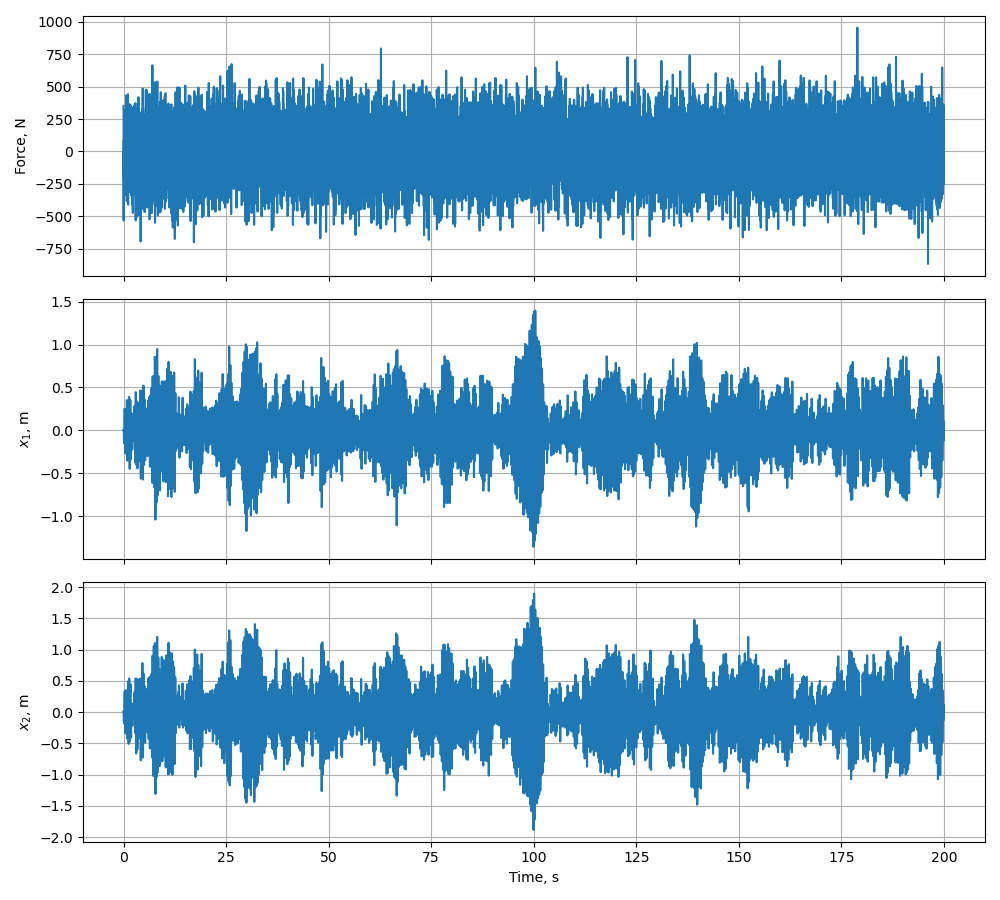

In [3]:
import numpy as np  # import numpy library for numerical calculations
from scipy.interpolate import interp1d  # import interp1d function for interpolation
from scipy.integrate import odeint  # import odeint function for solving ODEs
import matplotlib.pyplot as plt  # import matplotlib library for plotting

# Enable interactive plots
%matplotlib widget

# Create time array
t_span = 200  # [s]
f_sampling = 100  # sampling frequency [Hz]
t_vector = np.arange(0, t_span, 1 / f_sampling)  # time vector [s]

# Generate random force signal
np.random.seed(11)  # set random seed for reproducibility
force_rms = 200  # RMS of the force signal [N]
random_signal = np.random.normal(
    size=len(t_vector)
)  # random signal with normal distribution centered at 0
random_force_signal = random_signal * (
    force_rms / np.sqrt(np.mean(random_signal**2))
)  # scale random signal to desired RMS [N]

# Create interpolated force function
random_force_function = interp1d(
    t_vector, random_force_signal, bounds_error=False, fill_value=0
)

# Solve ODE
initial_state = [0, 0, 0, 0]  # zero-displacement and zero-velocity initial conditions
solution = odeint(
    two_dof_mass_spring_damper, initial_state, t_vector, args=(random_force_function,)
)

# Extract displacements at the two degrees of freedom
displacements = solution[:, :2].T

# Create figure with three subplots
fig, axes = plt.subplots(3, 1, sharex=True, figsize=(10, 9))

# Plot force
random_force_signal = random_force_function(t_vector)
axes[0].plot(t_vector, random_force_signal)
axes[0].set_ylabel("Force, N")
axes[0].grid(True)

# Plot displacement
axes[1].plot(t_vector, displacements[0])
axes[1].set_ylabel("$x_1$, m")
axes[1].grid(True)

# Plot velocity
axes[2].plot(t_vector, displacements[1])
axes[2].set_ylabel("$x_2$, m")
axes[2].grid(True)
axes[2].set_xlabel("Time, s")

# Set layout and show plot
plt.tight_layout()
plt.show()

### Data Processing <a name="data-processing"></a>

We define the function `calculate_frf`, which calculates the FRF for each degree of freedom by dividing the FFT of the output displacement by the FFT of the input force. We then calculate the FRF for our data.

In [4]:
from scipy import fft

def calculate_frf(input_signal, output_signal_array):
    """
    Calculate the frequency response function (FRF) for a given input signal and output signal array.

    Parameters:
    input_signal (array): Input signal for which the FRF is calculated.
    output_signal_array (array): Array of output signals for which the FRF is calculated.

    Returns:
    array: Array of FRFs for each output signal.
    """
    # Calculate FFT for input signal
    input_fft = fft.fft(input_signal)

    # Calculate FFT for each output signal and corresponding FRF
    output_fft = np.zeros_like(output_signal_array, dtype=complex)
    frf = np.zeros_like(output_signal_array, dtype=complex)
    for i in range(output_signal_array.shape[0]):
        output_fft[i] = fft.fft(output_signal_array[i])
        frf[i] = output_fft[i] / input_fft

    return frf

# Calculate FRF for the random force signal and the two output signals
frf = calculate_frf(random_force_signal, displacements)

Let's define a function to plot the magnitude and phase of the FRF and let's plot the FRF for each degree of freedom.

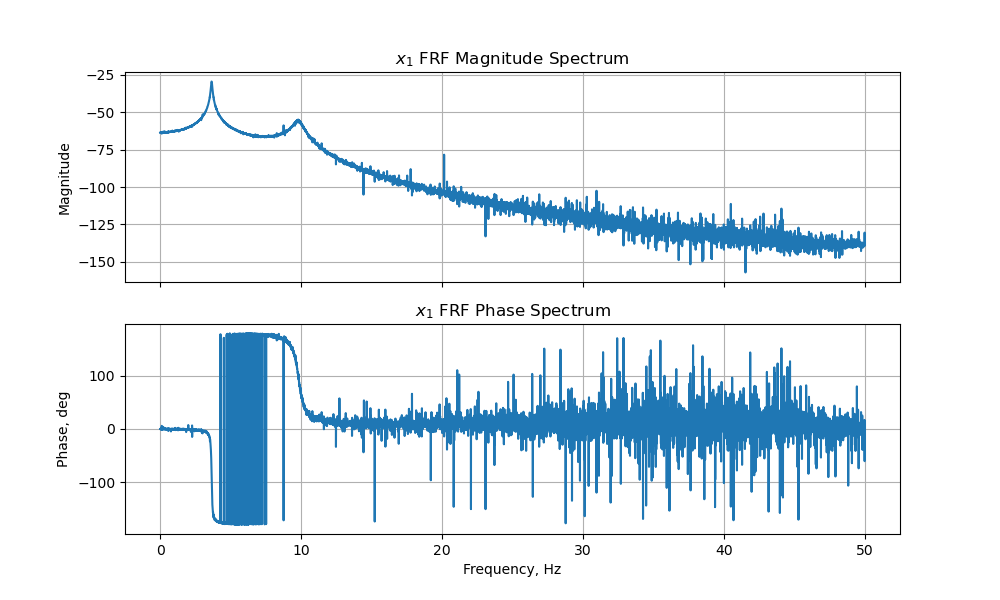

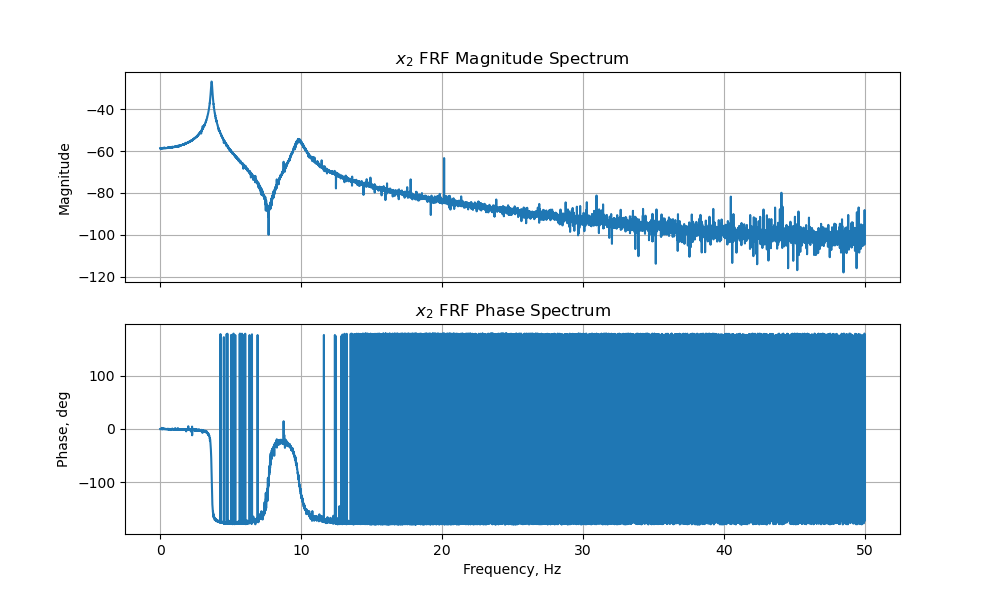

In [5]:
def plot_spectrum(frequencies, spectrum, title):
    """Plot magnitude and phase spectrum of a signal

    Parameters:
    frequencies (array): Frequency vector
    spectrum (array): Complex spectrum values
    title (str): Plot title
    """
    # Get positive frequencies only (since spectrum is symmetric for real signals)
    pos_mask = frequencies >= 0
    pos_freqs = frequencies[pos_mask]
    pos_spectrum = spectrum[pos_mask]

    # Calculate magnitude and phase
    magnitude_db = 20 * np.log10(np.abs(pos_spectrum))
    phase = np.angle(pos_spectrum, deg=True)

    # Create figure with two subplots
    fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)

    # Plot magnitude
    axes[0].plot(pos_freqs, magnitude_db)
    axes[0].set_ylabel("Magnitude")
    axes[0].grid(True)
    axes[0].set_title(f"{title} Magnitude Spectrum")

    # Plot phase
    axes[1].plot(pos_freqs, phase)
    axes[1].set_ylabel("Phase, deg")
    axes[1].set_xlabel("Frequency, Hz")
    axes[1].grid(True)
    axes[1].set_title(f"{title} Phase Spectrum")

    return fig, axes

# Plot FRF spectrum for each degree of freedom
frequencies = np.fft.fftfreq(len(t_vector), 1 / f_sampling)
_, _ = plot_spectrum(frequencies, frf[0], "$x_1$ FRF")
plt.show()
_, _ = plot_spectrum(frequencies, frf[1], "$x_2$ FRF")
plt.show()

Before calculating the IRF, let's clean the FRF by applying a Savitzky-Golay filter.

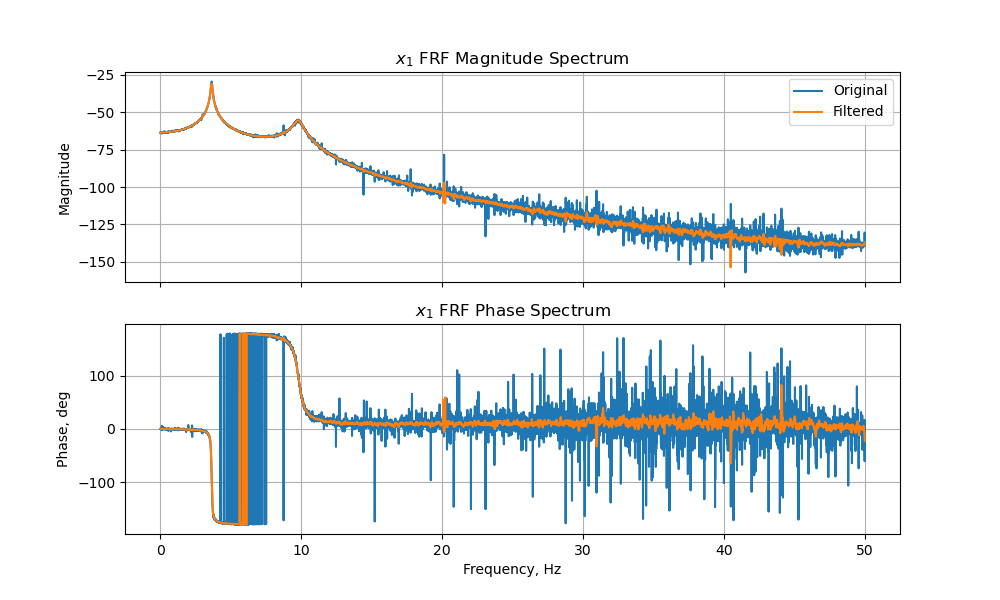

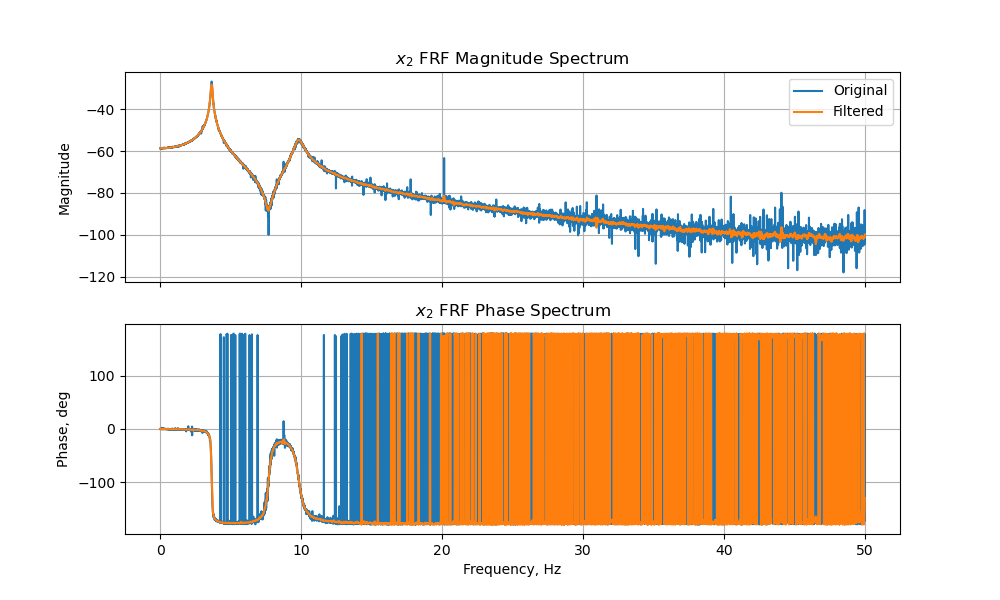

In [6]:
from scipy import signal

# Define Savitzky-Golay filter parameters
window_length = 31
polyorder = 3

# Get positive-frequency portion of the FRF
pos_mask = frequencies >= 0
pos_freqs = frequencies[pos_mask]

# Initialize filtered FRF array
pos_spectrum_filtered = np.zeros((DOF, len(pos_freqs)), dtype=complex)

# Iterate over the degrees of freedom
for i in range(DOF):
    # Get positive-frequency portion of the FRF
    pos_spectrum = frf[i, pos_mask]

    # Apply Savitzky-Golay filter for smoothing
    real_filtered = signal.savgol_filter(pos_spectrum.real, window_length, polyorder)
    imag_filtered = signal.savgol_filter(pos_spectrum.imag, window_length, polyorder)
    pos_spectrum_filtered[i] = real_filtered + 1j * imag_filtered

    # Plot original FRF to compare with filtered FRF
    fig, axes = plot_spectrum(frequencies, frf[i], f"$x_{i+1:d}$ FRF")

    # Calculate magnitude and phase of the filtered FRF
    magnitude_db = 20 * np.log10(np.abs(pos_spectrum_filtered[i]))
    phase = np.angle(pos_spectrum_filtered[i], deg=True)

    # Plot magnitude
    axes[0].plot(pos_freqs, magnitude_db)
    axes[0].legend(["Original", "Filtered"])

    # Plot phase
    axes[1].plot(pos_freqs, phase)

    # Show plot
    plt.show()

### Parameter Estimation <a name="parameter-estimation"></a>

We can now estimate the parameters of the system using the LSCE algorithm. We start by defining the function `estimate_lsce_parameters`, which takes as input the FRF, calculates the IRF and computes the $\beta$ coefficients.

In [7]:
def estimate_lsce_parameters(frf):
    """
    Estimate the Least Squares Complex Exponential (LSCE) parameters

    Parameters:
    frf (array): displacements FRF with shape (2, N)

    Returns:
    array: Estimated LSCE parameters with shape (4, 1)
    """
    # Calculate IRF
    irf = np.fft.ifft(frf, axis=1).real

    # Find number of samples
    N = irf.shape[1]

    # Create output vector
    h = np.atleast_2d(np.hstack((irf[0, 4:], irf[1, 4:]))).T

    # Create observation matrix
    H = np.vstack(
        (
            np.vstack(
                ([irf[0, 0 : N - 4], irf[0, 1 : N - 3], irf[0, 2 : N - 2], irf[0, 3 : N - 1]])
            ).T,
            np.vstack(
                ([irf[1, 0 : N - 4], irf[1, 1 : N - 3], irf[1, 2 : N - 2], irf[1, 3 : N - 1]])
            ).T,
        )
    )

    # Calculate the LSCE parameters
    betas = np.linalg.lstsq(H, -h)[0]

    # Return the LSCE parameters
    return betas, irf

Then we define the function `estimate_modal_parameters` that computes the natural frequency and damping ratio of the system from the $\beta$ coefficients.

In [8]:
def estimate_modal_parameters(betas, fs):
    """
    Estimate the modal parameters

    Parameters:
    betas (array): Estimated LSCE parameters with shape (4, 1)
    fs (float): Sampling frequency [Hz]

    Returns:
    array: Natural frequencies of the modes [rad/s]
    array: Damping ratios of the modes
    array: Discrete-time poles
    """
    # Calculate the discrete-time poles
    lambdas = np.roots([1, betas[3, 0], betas[2, 0], betas[1, 0], betas[0, 0]])

    # The poles come in complex conjugate pairs for underdamped systems
    # Sort the poles to identify conjugate pairs
    
    # We'll pair the poles based on their absolute values (magnitudes)
    # First, sort by magnitude
    sorted_indices = np.argsort(np.abs(lambdas))
    lambdas_sorted = lambdas[sorted_indices]
    
    # Group the poles with similar magnitudes
    no_modes = betas.shape[0] // 2  # number of modes = number of betas / 2
    omegas = np.zeros(no_modes)
    zetas = np.zeros(no_modes)
    
    # Process each mode (pair of poles)
    for i in range(no_modes):
        # Take consecutive poles after sorting - they should be a conjugate pair
        lambda1 = lambdas_sorted[2*i]
        lambda2 = lambdas_sorted[2*i+1]
        
        # Verify these are actually a conjugate pair
        # If not, you might need a more sophisticated pairing algorithm
        if not np.isclose(np.abs(lambda1), np.abs(lambda2), rtol=1e-4):
            print(f"Warning: Poles {lambda1} and {lambda2} might not be a conjugate pair")
        
        # Calculate natural frequency and damping ratio
        # We take the square root of the product of logarithms
        omega = fs * np.sqrt(np.log(lambda1) * np.log(lambda2))

        # Calculate the damping ratio using the product of the poles
        zeta = -fs * np.log(lambda1 * lambda2) / (2 * omega)

        # Take the real part of the natural frequency and damping ratio
        omegas[i] = np.real(omega)
        zetas[i] = np.real(zeta)

    # Return modal parameters and lambdas
    return omegas, zetas, lambdas_sorted

Finally, we can define the function `estimate_mode_shapes` to estimate the mode shapes from the residues, which in turn are obtained from the discrete-time poles $\lambda$.

In [9]:
def estimate_mode_shapes(irf, lambdas, omegas, zetas):
    """
    Compare measured and estimated output using ARX parameters

    Parameters:
    irf (array): Displacements IRF with shape (2, N)
    lambdas (array): Discrete-time poles
    omegas (array): Natural frequencies of the modes [rad/s]
    zetas (array): Damping ratios of the modes
    """
    # Find number of samples
    N = irf.shape[1]

    # Calculate the number of poles and modes
    no_poles = lambdas.shape[0]  # number of poles = number of lambdas
    no_modes = no_poles // 2  # number of modes = number of poles / 2

    # Initialize array of residues
    residues = np.zeros((no_modes, no_poles))

    # Initialize array of modes
    modes = np.zeros((irf.shape[0], no_modes))

    # Assemble matrix of lambdas
    lambda_matrix = np.vstack([l**np.arange(no_poles) for l in lambdas]).T

    # Iterate over each mode
    for i in range(no_modes):
        h = irf[i, 0:no_poles].T
        res = np.linalg.solve(lambda_matrix, h)
        a1 = res[0]*2j*omegas[i]*np.sqrt(1-zetas[i]**2)
        modes[:, i] = np.array([a1.real, 1])

    # Return the modes
    return modes

We apply these functions to the raw FRF and print the estimated natural frequency and damping ratio.

In [10]:
# Estimate LSCE parameters and modal parameters
betas, irf = estimate_lsce_parameters(frf)
omegas, zetas, lambdas = estimate_modal_parameters(betas, f_sampling)

# Take sorted true natural frequencies and damping ratiosn for comparison
true_sorted_indices = np.argsort(natural_frequencies)
sorted_natural_frequencies = natural_frequencies[true_sorted_indices]
sorted_damping_ratios = damping_ratios[true_sorted_indices]

# Take sorted estimated natural frequencies and damping ratios
est_sorted_indices = np.argsort(omegas)
sorted_omegas = omegas[est_sorted_indices]
sorted_zetas = zetas[est_sorted_indices]

# Compare true and estimated natural frequencies and damping ratios for each mode
for i in range(DOF):
    print(f"Mode {i+1:d}")
    print(f"True natural frequency: {sorted_natural_frequencies[i]:.2f} rad/s")
    print(f"Estimated natural frequency: {sorted_omegas[i]:.2f} rad/s")
    print(f"Percentage error: {100 * (sorted_omegas[i]/sorted_natural_frequencies[i] - 1):.2f}%")
    print(f"True damping ratio: {sorted_damping_ratios[i]:.2f}")
    print(f"Estimated damping ratio: {sorted_zetas[i]:.2f}")
    print(f"Percentage error: {100 * (sorted_zetas[i]/sorted_damping_ratios[i] - 1):.2f}%\n")
    print()


Mode 1
True natural frequency: 22.92 rad/s
Estimated natural frequency: 23.02 rad/s
Percentage error: 0.44%
True damping ratio: 0.01
Estimated damping ratio: 0.04
Percentage error: 259.42%


Mode 2
True natural frequency: 61.71 rad/s
Estimated natural frequency: 68.57 rad/s
Percentage error: 11.11%
True damping ratio: 0.03
Estimated damping ratio: 0.24
Percentage error: 661.78%




Let's find the mode shapes.

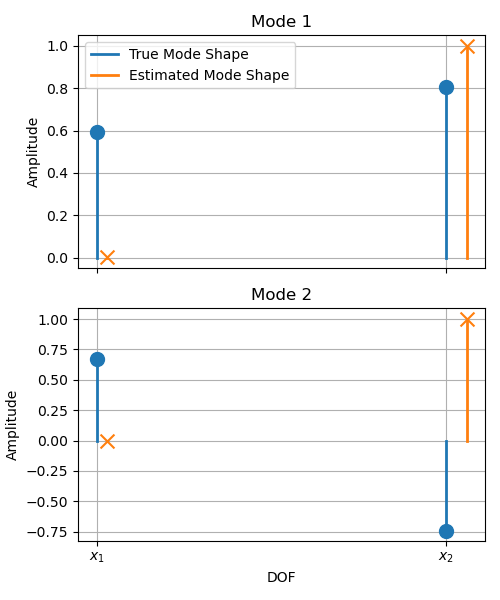

In [11]:
# Calculate estimated mode shapes
estimated_phi = estimate_mode_shapes(irf, lambdas, omegas, zetas)

# Normalize estimated mode shapes to unit length
normalized_estimated_phi = np.zeros_like(estimated_phi)
for i in range(DOF):
    normalized_estimated_phi[:, i] = estimated_phi[:, i] / np.linalg.norm(estimated_phi[:, i])

# Take sorted true mode shapes for comparison
sorted_modes = np.zeros_like(eigenvectors)
for i in range(DOF):
    sorted_modes[:, i] = eigenvectors[:, true_sorted_indices[i]]

# Get default matlpotlib colors
COLORS = plt.rcParams['axes.prop_cycle'].by_key()['color']

def plot_mode_shapes(true_modes, est_modes):
    """
    Plot true vs estimated mode shapes
    
    Parameters:
    true_modes: array of shape (n_dofs, n_modes) containing true mode shapes
    est_modes: array of shape (n_dofs, n_modes) containing estimated mode shapes
    """
    node_positions = np.arange(1, DOF + 1)

    # Create a figure with a subplot for each mode
    fig, axes = plt.subplots(DOF, 1, figsize=(5, 6), sharex=True)

    # Iterate over each mode
    for i in range(DOF):
        # Iterate over each degree of freedom
        for j in range(DOF):
            # Plot component of current degree of freedom for current mode shape
            true_line = axes[i].plot([j+1, j+1], [0, true_modes[j, i]], color=COLORS[0], label='True Mode Shape', linewidth=2)
            est_line = axes[i].plot(np.array([j+1, j+1])*1.03, [0, est_modes[j, i]], color=COLORS[1], label='Estimated Mode Shape', linewidth=2)
            
            # Plot markers
            axes[i].scatter(j+1, true_modes[j, i], color=COLORS[0], marker='o', s=100, zorder=5)
            axes[i].scatter((j+1)*1.03, est_modes[j, i], color=COLORS[1], marker='x', s=100, zorder=5)

        # Add labels and legend
        axes[i].set_title(f'Mode {i+1}')
        axes[i].set_ylabel('Amplitude')
        axes[i].grid(True)

    # Add labels and legend
    axes[0].legend([true_line[0], est_line[0]], ['True Mode Shape', 'Estimated Mode Shape'])
    axes[-1].set_xlabel('DOF')
    axes[-1].set_xticks(node_positions)
    axes[-1].set_xticklabels([f'$x_{i+1}$' for i in range(DOF)])
    
    # Set layout and show plot
    plt.tight_layout()
    plt.show()

# Plot true vs estimated mode shapes
plot_mode_shapes(sorted_modes, normalized_estimated_phi)

Now we apply the estimation to the filtered FRF.

Mode 1
True natural frequency: 22.92 rad/s
Estimated natural frequency: 22.79 rad/s
Percentage error: -0.55%
True damping ratio: 0.01
Estimated damping ratio: 0.02
Percentage error: 32.06%

Mode 2
True natural frequency: 61.71 rad/s
Estimated natural frequency: 64.61 rad/s
Percentage error: 4.69%
True damping ratio: 0.03
Estimated damping ratio: 0.10
Percentage error: 237.46%



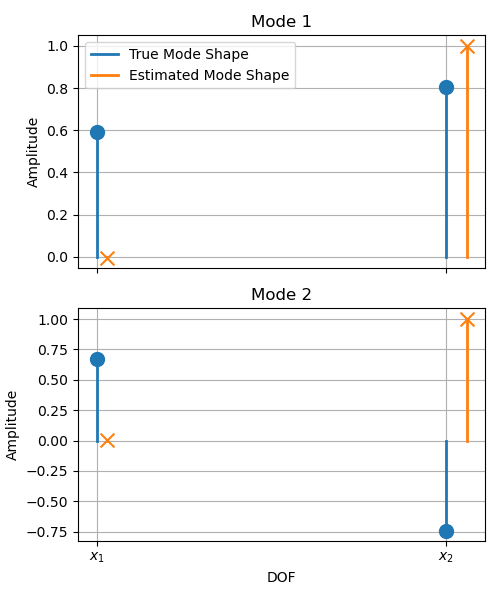

In [12]:
# Create full spectrum of filtered FRF by complex conjugate symmetry
full_filtered_spectrum = np.hstack(
    (pos_spectrum_filtered, np.conj(pos_spectrum_filtered[:, 1:-1][:, ::-1]))
)

# Estimate LSCE parameters and modal parameters
betas, irf = estimate_lsce_parameters(full_filtered_spectrum)
omegas, zetas, lambdas = estimate_modal_parameters(betas, f_sampling)

# Take sorted estimated natural frequencies and damping ratios
est_sorted_indices = np.argsort(omegas)
sorted_omegas = omegas[est_sorted_indices]
sorted_zetas = zetas[est_sorted_indices]

# Compare true and estimated natural frequencies and damping ratios for each mode
for i in range(DOF):
    print(f"Mode {i+1:d}")
    print(f"True natural frequency: {sorted_natural_frequencies[i]:.2f} rad/s")
    print(f"Estimated natural frequency: {sorted_omegas[i]:.2f} rad/s")
    print(f"Percentage error: {100 * (sorted_omegas[i]/sorted_natural_frequencies[i] - 1):.2f}%")
    print(f"True damping ratio: {sorted_damping_ratios[i]:.2f}")
    print(f"Estimated damping ratio: {sorted_zetas[i]:.2f}")
    print(f"Percentage error: {100 * (sorted_zetas[i]/sorted_damping_ratios[i] - 1):.2f}%\n")

# Calculate estimated mode shapes
estimated_phi = estimate_mode_shapes(irf, lambdas, omegas, zetas)

# Normalize estimated mode shapes to unit length
normalized_estimated_phi = np.zeros_like(estimated_phi)
for i in range(DOF):
    normalized_estimated_phi[:, i] = estimated_phi[:, i] / np.linalg.norm(estimated_phi[:, i])

# Plot true vs estimated mode shapes
plot_mode_shapes(sorted_modes, normalized_estimated_phi)